# PaySim Fraud Pattern Investigation & Feature Engineering Foundations
This notebook explores the behaviors of fraudulent transactions in detail, investigates balance anomalies, and designs engineered features that will serve as inputs to our anomaly detection models in Week 2.

## Step 1: Import Required Libraries and Load Dataset
We import our analysis libraries and read the synthetic PaySim dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/paysim.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,103,PAYMENT,7715.92,C8050976,342650.21,334934.29,M1280147,0.00,0.00,0,0
1,436,CASH_OUT,38617.68,C2241066,22693.99,0.00,C4771771,2693.16,41310.84,0,0
2,271,TRANSFER,3613.05,C7153709,216851.34,213238.29,C3954331,5540.74,9153.79,0,0
3,107,CASH_IN,4026.08,C4803002,698393.24,702419.32,C9818262,342587.05,338560.97,0,0
4,72,PAYMENT,133798.08,C8421881,15782.89,0.00,M1858746,0.00,0.00,0,0


## Step 2: Isolate Fraudulent Transactions
To identify specific fraud patterns, we filter the dataset to analyze only transactions labeled as fraud (`isFraud == 1`).

In [2]:
fraud_df = df[df['isFraud'] == 1]
print(f'Total Fraud Cases: {fraud_df.shape[0]}')
fraud_df.head()

Total Fraud Cases: 130


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
766,145,CASH_OUT,117055.36,C9744113,117055.36,0.0,C9575164,0.00,0.00,1,0
933,470,TRANSFER,238380.68,C5543500,238380.68,0.0,C8239609,90206.83,328587.51,1,1
1533,344,CASH_OUT,57222.82,C1950324,57222.82,0.0,C1941899,57519.62,114742.44,1,0
2055,517,CASH_OUT,19406.49,C3076909,19406.49,0.0,C9559904,0.00,0.00,1,0
2164,494,CASH_OUT,894931.74,C8048258,894931.74,0.0,C1521149,0.00,0.00,1,0


## Step 3: Analyze Transaction Types for Fraud
Check which transaction types fraudsters prefer and compare the counts across classes using a crosstab.

In [3]:
print('Fraud Transaction Type Counts:')
print(fraud_df['type'].value_counts())

print('Transaction Type vs Fraud crosstab:')
pd.crosstab(df['type'], df['isFraud'])

Fraud Transaction Type Counts:
type
CASH_OUT    107
TRANSFER     23
Name: count, dtype: int64
Transaction Type vs Fraud crosstab:


isFraud,0,1
type,,
CASH_IN,22192,0
CASH_OUT,34844,107
DEBIT,976,0
PAYMENT,32925,0
TRANSFER,8933,23


## Step 4: Transaction Amount Analysis
Inspect descriptive statistics of fraud transaction amounts and compare average amounts for legitimate vs. fraudulent records.

In [4]:
print('Fraud Transaction Amount Stats:')
print(fraud_df['amount'].describe())

print('Mean Transaction Amount by Class:')
print(df.groupby('isFraud')['amount'].mean())

Fraud Transaction Amount Stats:
count    1.300000e+02
mean     2.453859e+05
std      5.453832e+05
min      1.039280e+03
25%      1.547781e+04
50%      4.120277e+04
75%      2.122235e+05
max      4.122054e+06
Name: amount, dtype: float64
Mean Transaction Amount by Class:
isFraud
0     40657.688479
1    245385.901077
Name: amount, dtype: float64


## Step 5: Investigate Sender Account Balances
Examine the balance of the origin account before and after fraudulent transactions to look for drainage patterns.

In [5]:
fraud_df[['oldbalanceOrg', 'newbalanceOrig']].head(10)

,oldbalanceOrg,newbalanceOrig
766,117055.36,0.0
933,238380.68,0.0
1533,57222.82,0.0
2055,19406.49,0.0
2164,894931.74,0.0
2551,299284.23,0.0
3411,17700.36,0.0
3869,29387.58,0.0
5513,3444.91,0.0
6346,27167.76,0.0


## Step 6: Investigate Destination Account Balances
Examine the recipient account balance before and after fraudulent transactions.

In [6]:
fraud_df[['oldbalanceDest', 'newbalanceDest']].head(10)

,oldbalanceDest,newbalanceDest
766,0.00,0.00
933,90206.83,328587.51
1533,57519.62,114742.44
2055,0.00,0.00
2164,0.00,0.00
2551,60259.83,359544.06
3411,112395.27,130095.63
3869,1538273.92,1567661.50
5513,6697.85,10142.76
6346,14271.15,41438.91


## Step 7: Feature Engineering
Create new engineered variables based on our domain investigations:
1. `origin_balance_diff`: Balance difference in the sender's account.
2. `dest_balance_diff`: Balance difference in the recipient's account.
3. `amount_balance_ratio`: Ratio of transaction amount to the sender's starting balance.
4. `account_drained`: Binary flag indicating if the sender's account was completely emptied.
5. `high_value_txn`: Binary flag indicating if the transaction amount is in the top 5% of all amounts.

In [7]:
# Origin balance difference
df['origin_balance_diff'] = df['oldbalanceOrg'] - df['newbalanceOrig']

# Destination balance difference
df['dest_balance_diff'] = df['newbalanceDest'] - df['oldbalanceDest']

# Amount to balance ratio
df['amount_balance_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)

# Account drained flag
df['account_drained'] = (df['newbalanceOrig'] == 0).astype(int)

# High-value transaction flag (95th percentile threshold)
threshold = df['amount'].quantile(0.95)
df['high_value_txn'] = (df['amount'] > threshold).astype(int)

print('Features engineered successfully!')

Features engineered successfully!


## Step 8: Analyze New Features
Print descriptive statistics for the newly created features.

In [8]:
df[['origin_balance_diff', 'dest_balance_diff', 'amount_balance_ratio', 'account_drained', 'high_value_txn']].describe()

,origin_balance_diff,dest_balance_diff,amount_balance_ratio,account_drained,high_value_txn
count,1.000000e+05,1.000000e+05,100000.000000,100000.00000,100000.000000
mean,8.491042e+03,1.375452e+04,4.843309,0.21534,0.050000
std,7.139812e+04,8.610191e+04,52.630468,0.41106,0.217946
min,-3.047947e+06,-1.615121e+06,0.000005,0.00000,0.000000
25%,6.736300e+02,0.000000e+00,0.041599,0.00000,0.000000
50%,5.434955e+03,0.000000e+00,0.222765,0.00000,0.000000
75%,1.699317e+04,1.023743e+04,1.205306,0.00000,0.000000
max,4.122054e+06,1.252418e+07,7050.777273,1.00000,1.000000


## Step 9: Compare Feature Means by Fraud Status
Verify if our engineered features show noticeable differences between fraud and non-fraud classes.

In [9]:
df.groupby('isFraud')[['amount_balance_ratio', 'origin_balance_diff', 'dest_balance_diff', 'account_drained', 'high_value_txn']].mean()

,amount_balance_ratio,origin_balance_diff,dest_balance_diff,account_drained,high_value_txn
isFraud,,,,,
0,4.848312,8182.677881,13637.139710,0.214319,0.049635
1,0.999925,245385.901077,103926.388692,1.000000,0.330769


## Step 10: Correlation Heatmap of All Features
Analyze the linear correlations of our raw and engineered features with the target label `isFraud`.

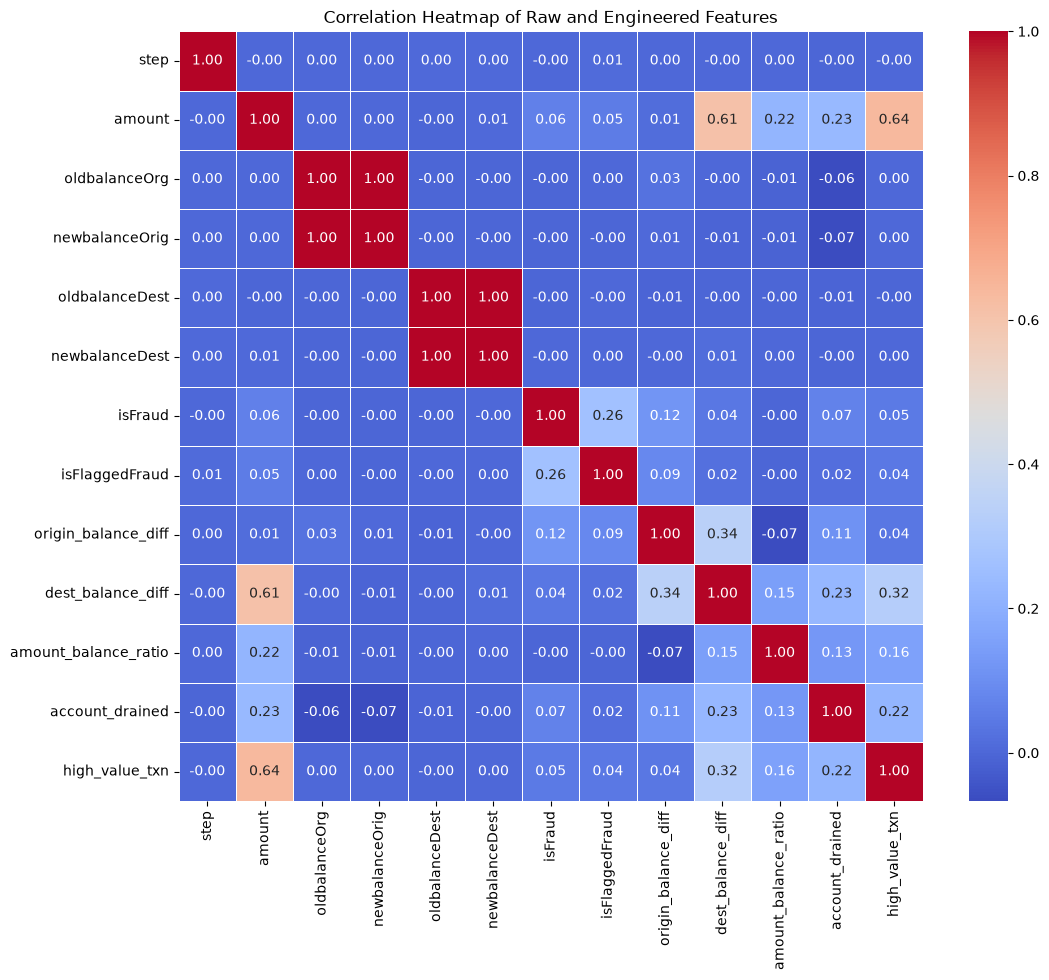

In [10]:
plt.figure(figsize=(12, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Raw and Engineered Features')
plt.savefig('feature_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 11: Save Engineered Dataset
Save the finalized DataFrame with the new features to `data/paysim_engineered.csv` for model training.

In [11]:
df.to_csv('../data/paysim_engineered.csv', index=False)
print('Engineered dataset successfully saved!')

Engineered dataset successfully saved!
